In [3]:
import pandas as pd
import plotly.express as px
import numpy as np

In [16]:
df = pd.read_csv("Gaming_Academic_Performance.csv")

In [5]:
conditions = [
    df["grades"] >= 80,  # good
    df["grades"] >= 55,  # sufficient
]
choices = ["good", "sufficient"]

df["grade_category"] = np.select(conditions, choices, default="fail")

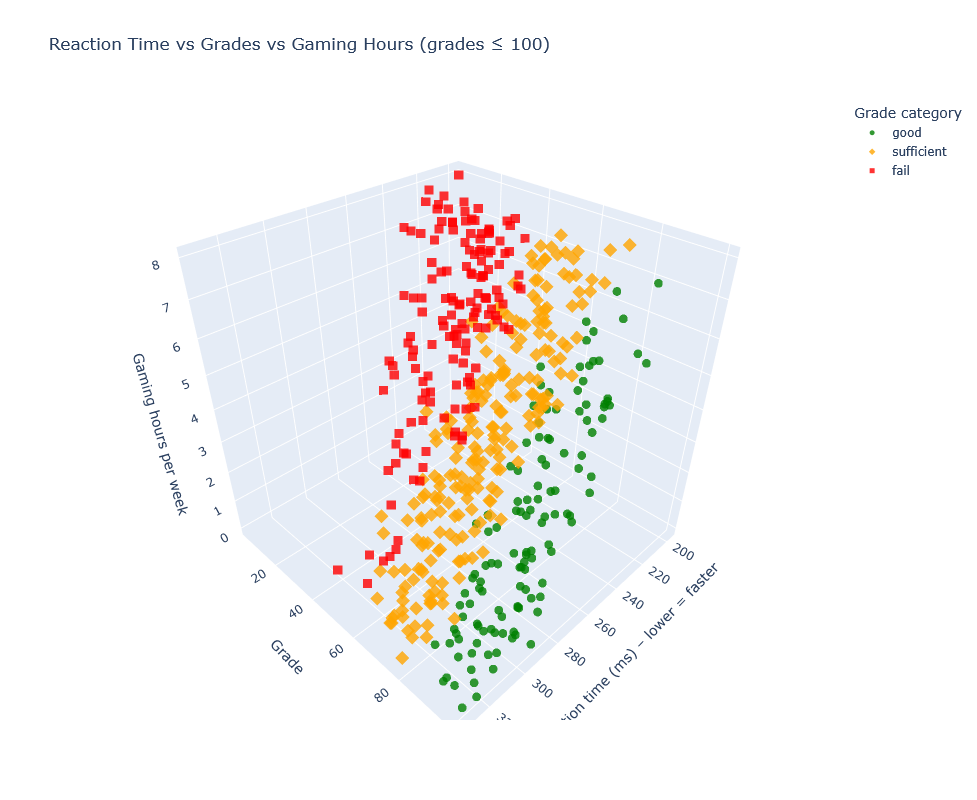

In [19]:
# 2. Create grade_category from grades
#   < 60      -> fail
#   60–79     -> sufficient
#   80+       -> good
df["grade_category"] = pd.cut(
    df["grades"],
    bins=[0, 55, 80, float("inf")],
    labels=["fail", "sufficient", "good"],
    right=False
)

# 3. Filter out unrealistic grades > 100
df_filtered = df[df["grades"] <= 100].copy()

# 4. Take a smaller sample if there are many rows (to make the plot clearer)
#    - If more than 500 rows, randomly sample 500
#    - Otherwise, use all filtered rows
if len(df_filtered) > 500:
    df_small = df_filtered.sample(n=500, random_state=0)
else:
    df_small = df_filtered.copy()

# 5. 3D scatter plot: Reaction time vs Grades vs Gaming hours
fig = px.scatter_3d(
    df_small,
    x="reaction_time_ms",
    y="grades",
    z="gaming_hours",
    color="grade_category",      # color by category
    symbol="grade_category",     # different marker symbols per category
    hover_data=[
        "gaming_hours",
        "study_hours",
        "reaction_time_ms",
        "grades",
    ],
    labels={
        "reaction_time_ms": "Reaction time (ms) ",
        "grades": "Grade ",
        "gaming_hours": "Gaming hours/week ",
        "grade_category": "Grade category ",
        "study_hours": "Study hours/week ",
    },
    color_discrete_map={
        "fail": "red",
        "sufficient": "orange",
        "good": "green",
    },
    title="Reaction Time vs Grades vs Gaming Hours (grades ≤ 100)",
    width=1000,
    height=800,
)

# Make points easier to see
fig.update_traces(marker=dict(size=5, opacity=0.8))

# Improve axis labels and legend
fig.update_layout(
    scene=dict(
        xaxis_title="Reaction time (ms) – lower = faster",
        yaxis_title="Grade",
        zaxis_title="Gaming hours per week",
    ),
    legend_title_text="Grade category"
)

fig.show()